In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import copy
from skimage.metrics import structural_similarity, mean_squared_error

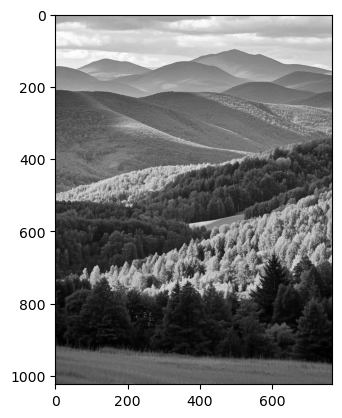

In [2]:
image = cv2.imread('hills.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

plt.imshow(image_gray, cmap='gray')

# Наложение шума Гаусса и постоянного шума

In [3]:
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

array([[  0,  16,   0, ...,   0,   0,  39],
       [ 30,  28,   7, ...,   0,   0,  51],
       [ 49,   0,  23, ...,   0, 230,   0],
       ...,
       [ 49,   0, 135, ..., 106,  74,  54],
       [182,   0,  87, ...,  52,   0,   0],
       [  0,   0,  79, ...,   0,  64,  88]],
      shape=(1024, 768), dtype=uint8)

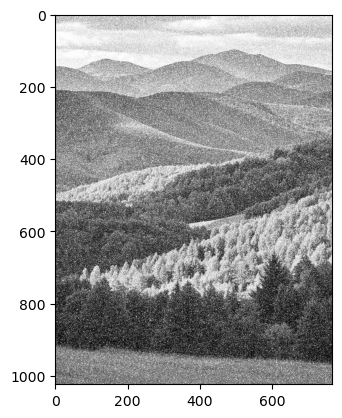

In [4]:
image_noise_gauss = cv2.add(image_gray, noise_gauss)

plt.imshow(image_noise_gauss, cmap='gray')

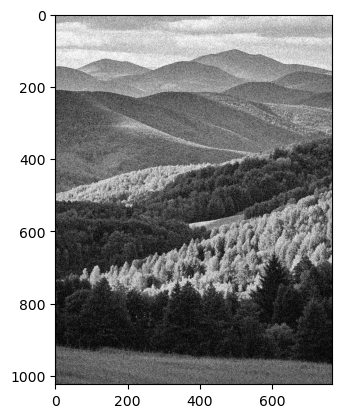

In [6]:
noise = np.random.randint(-50, 51, size=(image_gray.shape[0], image_gray.shape[1]), dtype=int)
image_uniform = np.clip(image_gray.astype(np.int16) + noise, 0, 255).astype(np.uint8)

plt.imshow(image_uniform, cmap="gray")

# MSE, SSIM зашумлённых картинок

In [7]:
mse_gauss = mean_squared_error(image_gray, image_noise_gauss)
(ssim, diff) = structural_similarity(image_gray, image_noise_gauss, full=True)
print(mse_gauss, ssim)

3505.0750617980957 0.19286728458654934


In [28]:
mse_uniform = mean_squared_error(image_gray, image_uniform)
(ssim_uniform, diff) = structural_similarity(image_gray, image_uniform, full=True)
print(mse_uniform, ssim_uniform)

786.9846445719401 0.3223872206091508


# Фильтры

## Медианный фильтр

### c шумом Гаусса

1045.9412117004395 0.3046045317876606


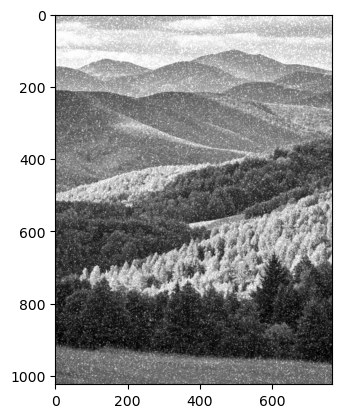

In [10]:
image_gauss_median_3 = cv2.medianBlur(image_noise_gauss, 3)

mse_gauss_median_3 = mean_squared_error(image_gray, image_gauss_median_3)
(ssim_gauss_median_3, diff) = structural_similarity(image_gray, image_gauss_median_3, full=True)

print(mse_gauss_median_3, ssim_gauss_median_3)
plt.imshow(image_gauss_median_3, cmap='gray')

630.0545616149902 0.4606443653624373


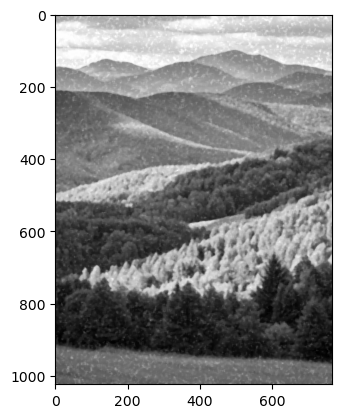

In [11]:
image_gauss_median_7 = cv2.medianBlur(image_noise_gauss, 7)

mse_gauss_median_7 = mean_squared_error(image_gray, image_gauss_median_7)
(ssim_gauss_median_7, diff) = structural_similarity(image_gray, image_gauss_median_7, full=True)

print(mse_gauss_median_7, ssim_gauss_median_7)
plt.imshow(image_gauss_median_7, cmap='gray')

### c постоянным шумом

374.4183718363444 0.3924097127144609


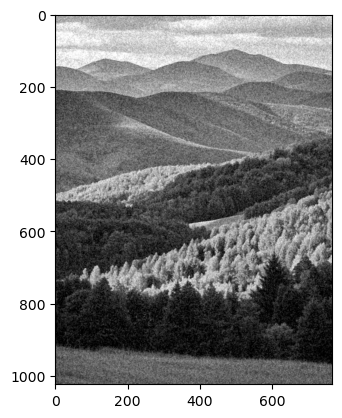

In [12]:
image_uniform_median_3 = cv2.medianBlur(image_uniform, 3)

mse_uniform_median_3 = mean_squared_error(image_gray, image_uniform_median_3)
(ssim_uniform_median_3, diff) = structural_similarity(image_gray, image_uniform_median_3, full=True)
print(mse_uniform_median_3, ssim_uniform_median_3)

plt.imshow(image_uniform_median_3, cmap='gray')

300.8001848856608 0.5007899963751601


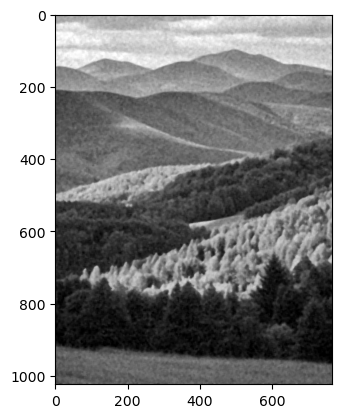

In [13]:
image_uniform_median_7 = cv2.medianBlur(image_uniform, 7)

mse_uniform_median_7 = mean_squared_error(image_gray, image_uniform_median_7)
(ssim_uniform_median_7, diff) = structural_similarity(image_gray, image_uniform_median_7, full=True)
print(mse_uniform_median_7, ssim_uniform_median_7)

plt.imshow(image_uniform_median_7, cmap='gray')

## Фильтр Гаусса

### c шумом Гаусса

1544.4773635864258 0.41525516207431196


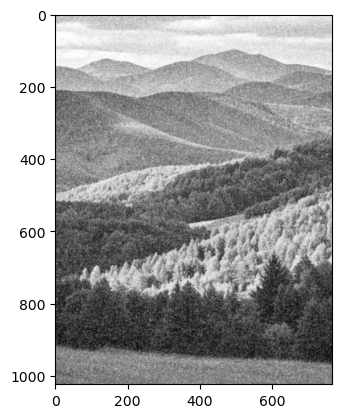

In [14]:
image_gauss_gauss_5 = cv2.GaussianBlur(image_noise_gauss, (5, 5), 0)

mse_gauss_gauss_5 = mean_squared_error(image_gray, image_gauss_gauss_5)
(ssim_gauss_gauss_5, diff) = structural_similarity(image_gray, image_gauss_gauss_5, full=True)

print(mse_gauss_gauss_5, ssim_gauss_gauss_5)
plt.imshow(image_gauss_gauss_5, cmap='gray')

1499.9423802693684 0.47090699047444595


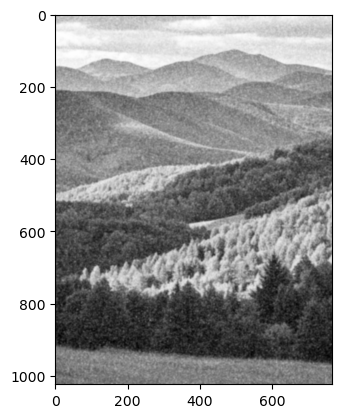

In [15]:
image_gauss_gauss_9 = cv2.GaussianBlur(image_noise_gauss, (9, 9), 0)

mse_gauss_gauss_9 = mean_squared_error(image_gray, image_gauss_gauss_9)
(ssim_gauss_gauss_9, diff) = structural_similarity(image_gray, image_gauss_gauss_9, full=True)

print(mse_gauss_gauss_9, ssim_gauss_gauss_9)
plt.imshow(image_gauss_gauss_9, cmap='gray')

### с постоянным шумом

218.50053914388022 0.5913823766038796


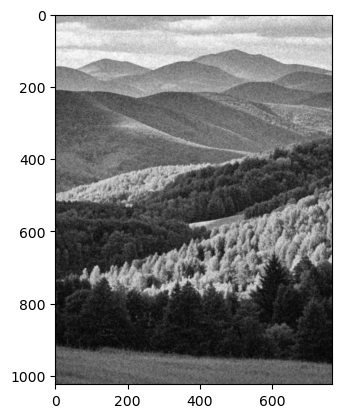

In [16]:
image_uniform_gauss_5 = cv2.GaussianBlur(image_uniform, (5, 5), 0)

mse_uniform_gauss_5 = mean_squared_error(image_gray, image_uniform_gauss_5)
(ssim_uniform_gauss_5, diff) = structural_similarity(image_gray, image_uniform_gauss_5, full=True)
print(mse_uniform_gauss_5, ssim_uniform_gauss_5)

plt.imshow(image_uniform_gauss_5, cmap='gray')

244.90892537434897 0.6036365773166903


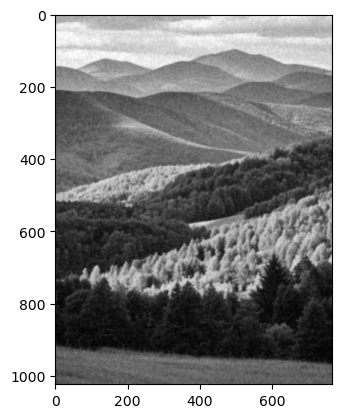

In [17]:
image_uniform_gauss_9 = cv2.GaussianBlur(image_uniform, (9, 9), 0)

mse_uniform_gauss_9 = mean_squared_error(image_gray, image_uniform_gauss_9)
(ssim_uniform_gauss_9, diff) = structural_similarity(image_gray, image_uniform_gauss_9, full=True)
print(mse_uniform_gauss_9, ssim_uniform_gauss_9)

plt.imshow(image_uniform_gauss_9, cmap='gray')

## Билатеральный фильтр

### с шумом Гаусса

1550.5126698811848 0.3474582437616015


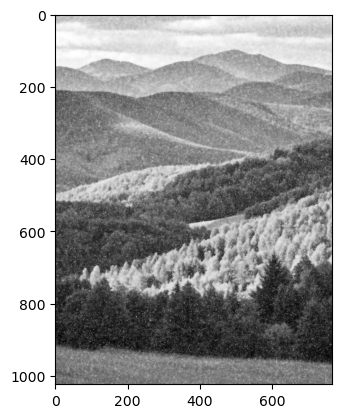

In [18]:
image_gauss_bilat_75 = cv2.bilateralFilter(image_noise_gauss, 9, 75, 75)

mse_gauss_bilat_75 = mean_squared_error(image_gray, image_gauss_bilat_75)
(ssim_gauss_bilat_75, diff) = structural_similarity(image_gray, image_gauss_bilat_75, full=True)
print(mse_gauss_bilat_75, ssim_gauss_bilat_75)

plt.imshow(image_gauss_bilat_75, cmap='gray')

1353.2814636230469 0.4590235494557896


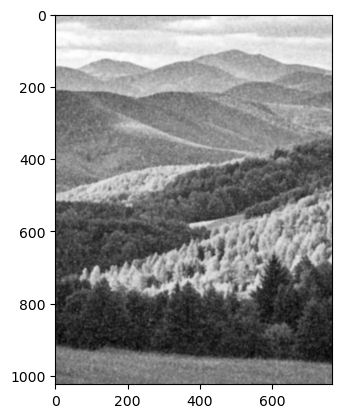

In [19]:
image_gauss_bilat_150 = cv2.bilateralFilter(image_noise_gauss, 9, 150, 150)

mse_gauss_bilat_150 = mean_squared_error(image_gray, image_gauss_bilat_150)
(ssim_gauss_bilat_150, diff) = structural_similarity(image_gray, image_gauss_bilat_150, full=True)
print(mse_gauss_bilat_150, ssim_gauss_bilat_150)

plt.imshow(image_gauss_bilat_150, cmap='gray')

### с постоянным шумом

185.27443567911783 0.6353895968860103


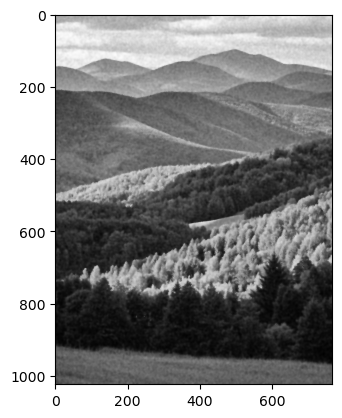

In [20]:
image_uniform_bilat_75 = cv2.bilateralFilter(image_uniform, 9, 75, 75)

mse_uniform_bilat_75 = mean_squared_error(image_gray, image_uniform_bilat_75)
(ssim_uniform_bilat_75, diff) = structural_similarity(image_gray, image_uniform_bilat_75, full=True)
print(mse_uniform_bilat_75, ssim_uniform_bilat_75)

plt.imshow(image_uniform_bilat_75, cmap='gray')

242.26309204101562 0.597148755567765


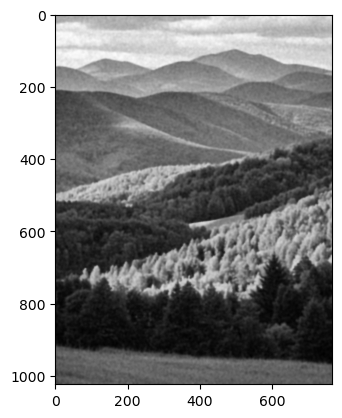

In [21]:
image_uniform_bilat_150 = cv2.bilateralFilter(image_uniform, 9, 150, 150)

mse_uniform_bilat_150 = mean_squared_error(image_gray, image_uniform_bilat_150)
(ssim_uniform_bilat_150, diff) = structural_similarity(image_gray, image_uniform_bilat_150, full=True)
print(mse_uniform_bilat_150, ssim_uniform_bilat_150)

plt.imshow(image_uniform_bilat_150, cmap='gray')

## Фильтр нелокальных средних

### с шумом Гаусса

3498.8860371907554 0.20758849146259992


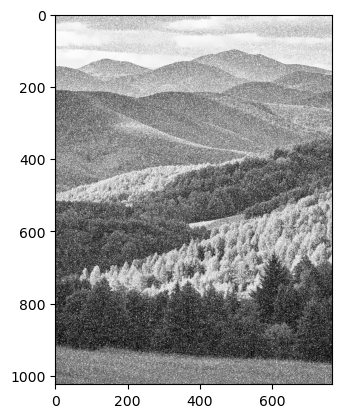

In [22]:
image_gauss_nlm_10 = cv2.fastNlMeansDenoising(image_noise_gauss, h = 10)

mse_gauss_nlm_10 = mean_squared_error(image_gray, image_gauss_nlm_10)
(ssim_gauss_nlm_10, diff) = structural_similarity(image_gray, image_gauss_nlm_10, full=True)
print(mse_gauss_nlm_10, ssim_gauss_nlm_10)

plt.imshow(image_gauss_nlm_10, cmap='gray')

3426.224526723226 0.25502097243295824


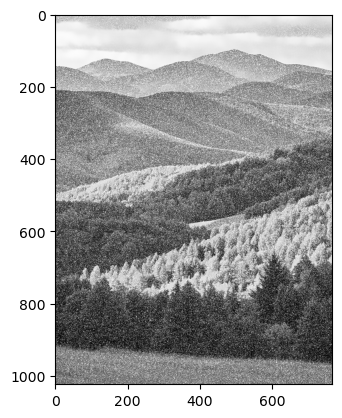

In [23]:
image_gauss_nlm_20 = cv2.fastNlMeansDenoising(image_noise_gauss, h = 20)

mse_gauss_nlm_20 = mean_squared_error(image_gray, image_gauss_nlm_20)
(ssim_gauss_nlm_20, diff) = structural_similarity(image_gray, image_gauss_nlm_20, full=True)
print(mse_gauss_nlm_20, ssim_gauss_nlm_20)

plt.imshow(image_gauss_nlm_20, cmap='gray')

### с постоянным шумом

782.808900197347 0.32405626663611725


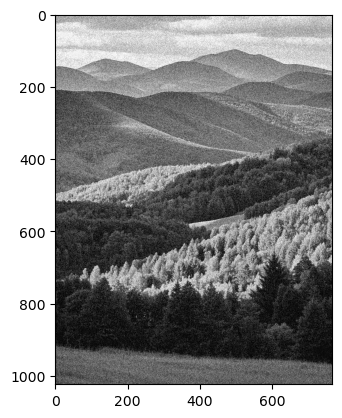

In [24]:
image_uniform_nlm_10 = cv2.fastNlMeansDenoising(image_uniform, h = 10)

mse_uniform_nlm_10 = mean_squared_error(image_gray, image_uniform_nlm_10)
(ssim_uniform_nlm_10, diff) = structural_similarity(image_gray, image_uniform_nlm_10, full=True)
print(mse_uniform_nlm_10, ssim_uniform_nlm_10)

plt.imshow(image_uniform_nlm_10, cmap='gray')

241.32452646891275 0.6248064425693495


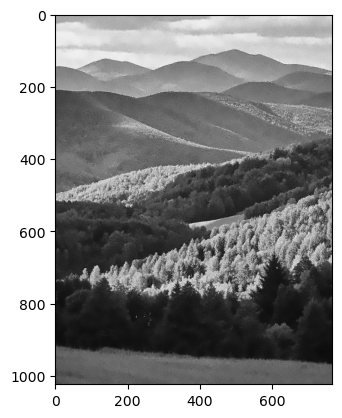

In [25]:
image_uniform_nlm_20 = cv2.fastNlMeansDenoising(image_uniform, h = 20)

mse_uniform_nlm_20 = mean_squared_error(image_gray, image_uniform_nlm_20)
(ssim_uniform_nlm_20, diff) = structural_similarity(image_gray, image_uniform_nlm_20, full=True)
print(mse_uniform_nlm_20, ssim_uniform_nlm_20)

plt.imshow(image_uniform_nlm_20, cmap='gray')

# Вывод

In [29]:
print("Сравнение результатов для шума Гаусса")
print(f"Медианный: MSE = {mse_gauss_median_7:.2f}, SSIM = {ssim_gauss_median_7:.4f}")
print(f"Гаусса: MSE = {mse_gauss_gauss_9:.2f}, SSIM = {ssim_gauss_gauss_9:.4f}")
print(f"Билатеральный: MSE = {mse_gauss_bilat_150:.2f}, SSIM = {ssim_gauss_bilat_150:.4f}")
print(f"Нелокальных средних: MSE = {mse_gauss_nlm_20:.2f}, SSIM = {ssim_gauss_nlm_20:.4f}")

Сравнение результатов для шума Гаусса
Медианный: MSE = 630.05, SSIM = 0.4606
Гаусса: MSE = 1499.94, SSIM = 0.4709
Билатеральный: MSE = 1353.28, SSIM = 0.4590
Нелокальных средних: MSE = 3426.22, SSIM = 0.2550


In [30]:
print("Сравнение результатов для постоянного шума")
print(f"Медианный: MSE = {mse_uniform_median_7:.2f}, SSIM = {ssim_uniform_median_7:.4f}")
print(f"Гаусса: MSE = {mse_uniform_gauss_5:.2f}, SSIM = {ssim_uniform_gauss_5:.4f}")
print(f"Билатеральный: MSE = {mse_uniform_bilat_75:.2f}, SSIM = {ssim_uniform_bilat_75:.4f}")
print(f"Нелокальных средних: MSE = {mse_uniform_nlm_20:.2f}, SSIM = {ssim_uniform_nlm_20:.4f}")

Сравнение результатов для постоянного шума
Медианный: MSE = 300.80, SSIM = 0.5008
Гаусса: MSE = 218.50, SSIM = 0.5914
Билатеральный: MSE = 185.27, SSIM = 0.6354
Нелокальных средних: MSE = 241.32, SSIM = 0.6248


Для шума Гаусса лучший результат по MSE показал медианный фильтр, а по SSIM — фильтр Гаусса, хотя оба фильтра дали очень близкие значения по SSIM. Билатеральный фильтр показал похожий, чуть более слабый результат. Фильтр нелокальных средних заметно уступил остальным.

Для постоянного шума лидирует билатеральный фильтр: у него одновременно и наименьшая ошибка, и наибольшее структурное сходство. Фильтр нелокальных средних показал неоднозначный результат: по SSIM он занял второе место после билатерального, обойдя фильтр Гаусса, но по MSE уступил фильтру Гаусса и занял третье место. Медианный фильтр здесь оказался слабейшим из всех и по MSE, и по SSIM.

В целом билатеральный фильтр демонстрирует наиболее стабильные результаты на обоих типах шума. Для шума Гаусса эффективны медианный и фильтр Гаусса, а фильтр нелокальных средних чувствителен к типу шума: на шуме Гаусса он оказался худшим, а на постоянном шуме — вторым после билатерального.